### Laboratorio de Escalonamento ###

Neste laboratório, iremos simular o funcionamento de algoritmos de escalonamento básicos para entender melhor seu funcionamento.

Na célula abaixo, temos uma classe Processo, que tem as informações de execução, e uma classe de exemplo de escalonamento apenas com os protótipos:

(orientação a objeto em Python)

In [ ]:
#pip install numpy

In [ ]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,prioridade,tempoChegada):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = tempoChegada
        self.tempoInicioExec = None
        self.tempoTerminoExec = None
        self.tempoResposta = None

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S

        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ", quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class escalonador(object): # Protótipo de escalonador de exemplo
    def __init__(self,vprontos=[]):
        self.prontos = vprontos #processos que cheam ao tempo zero

    def pronto(self,Processo):
        del self.prontos[0]
        self.prontos.append(Processo)
        return

    def proximo(self):
        # implemente aqui a política de escalonamento para definir um processo a ser executado
        if self.prontos[0].tam== 0:
          del self.prontos[0]
        return self.prontos[0]

Na célula abaixo, são criados quatro processos completamente CPU-Bound que precisam de 3 timeslices para rodar.

O valor de E/S é um número entre 0 e 100 indicando quantos porcento de chance o processo tem de fazer E/S durante seu tempo na CPU

In [ ]:
nprocs = 3
nomes = ['A','B','C']
chanceio = [0,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([5,5,5])


total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i],chanceio[i],tamanho[i],0,0)) #cria uma lista procs de Processos

Na célula abaixo, temos uma simulação do funcionamento de um escalonador de processos. As duas configurações importantes aqui são o valor do quantum padrão (que pode ser dinamico em algoritmos mais complexos, e quantos timeslices um processo que faz e/s passa bloqueado.

Percebam que na terceira linha é instanciado o escalonador (neste caso, um round_robin). Isto foi feito assim para ser simples trocar o escalonador e repetir a simulação, bastando criar uma classe com os métodos pronto, proximo e construtor e alterar esta linha.

In [ ]:
quantum = 1
tempoBloq = 1

escalonador = escalonador(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0
mediaTR = 0
total_tempos_exec = 0

random.seed(0)

while total>0:
    p = escalonador.proximo()
    if(p is not None):
        if p.tempoInicioExec is None:
            p.tempoInicioExec = tempo
            p.tempoResposta = p.tempoInicioExec - p.chegada

        rodou, _ = p.roda(quantum) #adicione quantum como parâmetro, por enquanto nao temos E/S

        if(p.tam>0):
            escalonador.pronto(p)
        else:
            p.tempoTerminoExec = tempo + quantum
            mediaTR += p.tempoResposta
            total_tempos_exec += p.tempoTerminoExec # Adiciona o tempo de execução ao somatório
        total -= rodou
        tempo += rodou

    else:
        for processo in escalonador.prontos:
            processo.tempoResposta += 1
        #Reduz o tempo de todos os bloqueados em uma unidade se nao havia ninguem pronto
        tempo += 1


print('Tempo de Resposta médio: ' + str(mediaTR/nprocs))
print('Tempo de Execução médio: ' + str(total_tempos_exec/nprocs))


A  rodou por  1  timeslice, faltam  4
B  rodou por  1  timeslice, faltam  4
C  rodou por  1  timeslice, faltam  4
A  rodou por  1  timeslice, faltam  3
B  rodou por  1  timeslice, faltam  3
C  rodou por  1  timeslice, faltam  3
A  rodou por  1  timeslice, faltam  2
B  rodou por  1  timeslice, faltam  2
C  rodou por  1  timeslice, faltam  2
A  rodou por  1  timeslice, faltam  1
B  rodou por  1  timeslice, faltam  1
C  rodou por  1  timeslice, faltam  1
A  rodou por  1  timeslice, faltam  0
B  rodou por  1  timeslice, faltam  0
C  rodou por  1  timeslice, faltam  0
Tempo de Resposta médio: 1.0
Tempo de Execução médio: 14.0


### Laboratório: ###


1 - Altere o simulador acima para calcular o tempo de execucao medio e tempo de resposta

2 - Implemente o escalonador por FIFO e SJF e verifique seus tempos de execução e espera.

3 - Faça em outra célula uma implementação do STCF e Round Robin, alterando o p.roda() para receber o quantum


Na segunda feira (15) haverá um questionário no ColabWeb onde você deverá utilizar suas implementações para responder às perguntas. Na terça de manhã farei uma breve conferência para tirar dúvidas.

# FIFO

In [1]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,prioridade,tempoChegada):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = tempoChegada
        self.tempoInicioExec = None
        self.tempoTerminoExec = None
        self.tempoResposta = None

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S

        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ", quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class escalonador(object): # Protótipo de escalonador de exemplo
    def __init__(self,vprontos=[]):
        self.prontos = vprontos #processos que cheam ao tempo zero

    def pronto(self,Processo):
        self.prontos.append(Processo)  # Adiciona ao final da lista (FIFO)
        return

    def proximo(self):
        if self.prontos:
            return self.prontos.pop(0)  # Remove e retorna o primeiro da lista (FIFO)
        return None

In [2]:
nprocs = 4
nomes = ['A','B','C','D']
chanceio = [0,0,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([10,20,30,40])


total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i],chanceio[i],tamanho[i],0,0)) #cria uma lista procs de Processos

In [3]:
quantum = 2
tempoBloq = 1

escalonador = escalonador(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0
mediaTR = 0
total_tempos_exec = 0

random.seed(0)

while total>0:
    p = escalonador.proximo()
    if(p is not None):
        if p.tempoInicioExec is None:
            p.tempoInicioExec = tempo
            p.tempoResposta = p.tempoInicioExec - p.chegada

        rodou, _ = p.roda() #adicione quantum como parâmetro, por enquanto nao temos E/S

        if(p.tam>0):
            escalonador.pronto(p)
        else:
            mediaTR += p.tempoResposta
        total -= rodou
        tempo += rodou
        p.tempoTerminoExec = tempo
        total_tempos_exec += p.tempoTerminoExec # Adiciona o tempo de execução ao somatório

    else:
        for processo in escalonador.prontos:
            processo.tempoResposta += 1
        #Reduz o tempo de todos os bloqueados em uma unidade se nao havia ninguem pronto
        tempo += 1


print('Tempo de Resposta médio: ' + str(mediaTR/nprocs))
print('Tempo de Execução médio: ' + str(total_tempos_exec/nprocs))


A  rodou por  10  timeslice, faltam  0
B  rodou por  20  timeslice, faltam  0
C  rodou por  30  timeslice, faltam  0
D  rodou por  40  timeslice, faltam  0
Tempo de Resposta médio: 25.0
Tempo de Execução médio: 50.0


# SJF

In [1]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,prioridade,tempoChegada):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = tempoChegada
        self.tempoInicioExec = None
        self.tempoTerminoExec = None
        self.tempoResposta = None

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S

        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ", quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class escalonador(object): # Protótipo de escalonador de exemplo
    def __init__(self,vprontos=[]):
        self.prontos = vprontos #processos que cheam ao tempo zero

    def pronto(self,Processo):
        self.prontos.append(Processo)

    def proximo(self):
        if len(self.prontos) == 0:
            return None

        self.prontos.sort(key=lambda processo: processo.tam)
        p = self.prontos.pop(0)  # Pega o processo com menor tempo restante

        return p  # processo p eh escolhido

In [2]:
nprocs = 3
nomes = ['A','B','C']
chanceio = [0,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([160,320,480])


total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i],chanceio[i],tamanho[i],0,0)) #cria uma lista procs de Processos

In [3]:
quantum = 2
tempoBloq = 1

escalonador = escalonador(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0
mediaTR = 0
total_tempos_exec = 0

random.seed(0)

while total>0:
    p = escalonador.proximo()
    if(p is not None):
        if p.tempoInicioExec is None:
            p.tempoInicioExec = tempo
            p.tempoResposta = p.tempoInicioExec - p.chegada

        rodou, _ = p.roda() #adicione quantum como parâmetro, por enquanto nao temos E/S

        if(p.tam>0):
            escalonador.pronto(p)
        else:
            mediaTR += p.tempoResposta
        total -= rodou
        tempo += rodou
        p.tempoTerminoExec = tempo
        total_tempos_exec += p.tempoTerminoExec # Adiciona o tempo de execução ao somatório

    else:
        for processo in escalonador.prontos:
            processo.tempoResposta += 1
        #Reduz o tempo de todos os bloqueados em uma unidade se nao havia ninguem pronto
        tempo += 1


print('Tempo de Resposta médio: ' + str(mediaTR/nprocs))
print('Tempo de Execução médio: ' + str(total_tempos_exec/nprocs))


A  rodou por  160  timeslice, faltam  0
B  rodou por  320  timeslice, faltam  0
C  rodou por  480  timeslice, faltam  0
Tempo de Resposta médio: 213.33333333333334
Tempo de Execução médio: 533.3333333333334


# Round Robin

In [1]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,prioridade,tempoChegada):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = tempoChegada
        self.tempoInicioExec = None
        self.tempoTerminoExec = None
        self.tempoResposta = None

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S

        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ", quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class escalonador(object): # Protótipo de escalonador de exemplo
    def __init__(self,vprontos=[]):
        self.prontos = vprontos #processos que cheam ao tempo zero

    def pronto(self,Processo):
        del self.prontos[0]
        self.prontos.append(Processo)
        return

    def proximo(self):
        # implemente aqui a política de escalonamento para definir um processo a ser executado
        if self.prontos[0].tam== 0:
          del self.prontos[0]
        return self.prontos[0]

In [2]:
nprocs = 5
nomes = ['A','B','C','D','E']
chanceio = [0,0,0,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([10,20,30,40,50])


total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i],chanceio[i],tamanho[i],0,0)) #cria uma lista procs de Processos

In [3]:
quantum = 32
tempoBloq = 1

escalonador = escalonador(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0
mediaTR = 0
total_tempos_exec = 0

random.seed(0)

while total>0:
    p = escalonador.proximo()
    if(p is not None):
        if p.tempoInicioExec is None:
            p.tempoInicioExec = tempo
            p.tempoResposta = p.tempoInicioExec - p.chegada

        rodou, _ = p.roda(quantum) #adicione quantum como parâmetro, por enquanto nao temos E/S

        if(p.tam>0):
            escalonador.pronto(p)
        else:
            p.tempoTerminoExec = tempo + quantum
            mediaTR += p.tempoResposta
            total_tempos_exec += p.tempoTerminoExec # Adiciona o tempo de execução ao somatório
        total -= rodou
        tempo += rodou

    else:
        for processo in escalonador.prontos:
            processo.tempoResposta += 1
        #Reduz o tempo de todos os bloqueados em uma unidade se nao havia ninguem pronto
        tempo += 1


print('Tempo de Resposta médio: ' + str(mediaTR/nprocs))
print('Tempo de Execução médio: ' + str(total_tempos_exec/nprocs))


A  rodou por  10  timeslice, faltam  0
B  rodou por  20  timeslice, faltam  0
C  rodou por  30  timeslice, faltam  0
D  rodou por  32  timeslice, faltam  8
E  rodou por  32  timeslice, faltam  18
D  rodou por  8  timeslice, faltam  0
E  rodou por  18  timeslice, faltam  0
Tempo de Resposta médio: 38.4
Tempo de Execução médio: 91.2


#STCF

In [1]:
import numpy as np
import random

class Processo(object):
    def __init__(self,pnome,pio,ptam,prioridade,tempoChegada):
        self.nome = pnome
        self.io = pio # Probabilidade de fazer E/S, inicialmente zero
        self.tam = ptam # Quantos Timeslices sao necessarios para terminar
        self.prio = prioridade # Prioridade, eh desnecessaria agora
        self.chegada = tempoChegada
        self.tempoInicioExec = None
        self.tempoTerminoExec = None
        self.tempoResposta = None

    def roda(self,quantum=None): # se rodar sem quantum, o processor roda ate o fim
        if(random.randint(1,100)<self.io): #Verifica se fez E/S
            self.tam-=1
            print(self.nome," fez e/s, falta ",self.tam)
            return 1, True #True que fez E/S

        if(quantum is None or self.tam<quantum):
            quantum = self.tam
        self.tam -=quantum
        print(self.nome," rodou por ", quantum," timeslice, faltam ",self.tam)
        return quantum, False # False se nao fez E/S


class escalonador(object): # Protótipo de escalonador de exemplo
    def __init__(self,vprontos=[]):
        self.prontos = vprontos #processos que cheam ao tempo zero

    def pronto(self,Processo):
        self.prontos.append(Processo)

    def proximo(self):
        # implemente aqui a política de escalonamento para definir um processo a ser executado
        if len(self.prontos) == 0:
            return None

        self.prontos.sort(key=lambda processo: processo.tam)
        p = self.prontos.pop(0)  # Pega o processo com menor tempo restante

        return p #processo p eh escolhido

In [2]:
nprocs = 4
nomes = ['A','B','C','D']
chanceio = [0,0,0,0] #Valor de zero a cem, chance de ser entrada e saida por enquanto deixem em zero
tamanho = np.array([10,40,30,20])


total = tamanho.sum()

procs = []
for i in range(nprocs):
    procs.append(Processo(nomes[i],chanceio[i],tamanho[i],0,0)) #cria uma lista procs de Processos

In [3]:
quantum = 10
tempoBloq = 1

escalonador = escalonador(procs) #troque escalonador pelo seu escalonador
bloqueados = []

tempo = 0
mediaTR = 0
total_tempos_exec = 0

random.seed(0)

while total>0:
    p = escalonador.proximo()
    if(p is not None):
        if p.tempoInicioExec is None:
            p.tempoInicioExec = tempo
            p.tempoResposta = p.tempoInicioExec - p.chegada

        rodou, _ = p.roda(quantum) #adicione quantum como parâmetro, por enquanto nao temos E/S

        if(p.tam>0):
            escalonador.pronto(p)
        else:
            mediaTR += p.tempoResposta
        total -= rodou
        tempo += rodou
        p.tempoTerminoExec = tempo
        total_tempos_exec += p.tempoTerminoExec # Adiciona o tempo de execução ao somatório

    else:
        for processo in escalonador.prontos:
            processo.tempoResposta += 1
        #Reduz o tempo de todos os bloqueados em uma unidade se nao havia ninguem pronto
        tempo += 1


print('Tempo de Resposta médio: ' + str(mediaTR/nprocs))
print('Tempo de Execução médio: ' + str(total_tempos_exec/nprocs))


A  rodou por  10  timeslice, faltam  0
D  rodou por  10  timeslice, faltam  10
D  rodou por  10  timeslice, faltam  0
C  rodou por  10  timeslice, faltam  20
C  rodou por  10  timeslice, faltam  10
C  rodou por  10  timeslice, faltam  0
B  rodou por  10  timeslice, faltam  30
B  rodou por  10  timeslice, faltam  20
B  rodou por  10  timeslice, faltam  10
B  rodou por  10  timeslice, faltam  0
Tempo de Resposta médio: 25.0
Tempo de Execução médio: 137.5


# Gráfico SJF

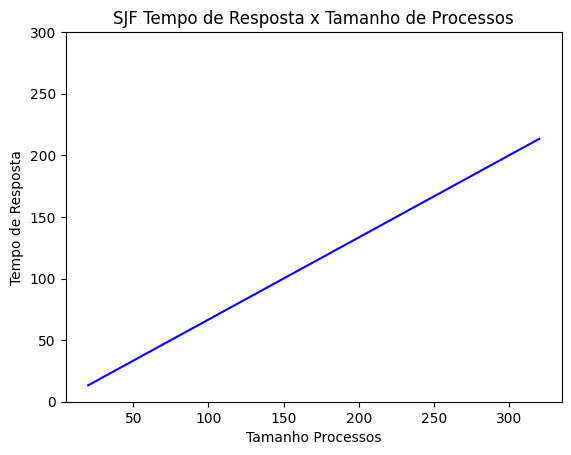

In [3]:
import matplotlib.pyplot as plt

# Dados para o eixo X e eixo Y1
tamanho_medio = [20, 40, 80, 160, 320]
tempo_resposta = [13.33, 26.66, 53.33, 106.66, 213.33]

# Criar uma figura e eixos
fig, ax1 = plt.subplots()

# Plotar os dados no primeiro eixo (esquerdo)
ax1.plot(tamanho_medio, tempo_resposta, 'b-')
ax1.set_xlabel('Tamanho Processos')
ax1.set_ylabel('Tempo de Resposta')
#ax1.tick_params(axis='y', labelcolor='g')

# Adicionar título ao gráfico
plt.ylim(0, 300)
plt.title('SJF Tempo de Resposta x Tamanho de Processos')

# Exibir o gráfico
plt.show()

# Gráfico Round Robin

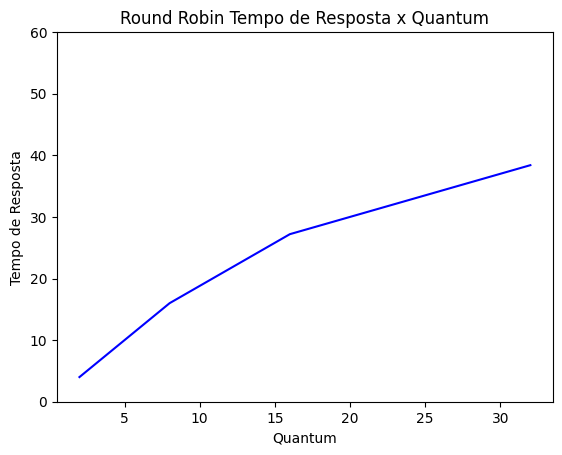

In [2]:
import matplotlib.pyplot as plt

# Dados para o eixo X e eixo Y1
quantum = [2, 4, 8, 16, 32]
tempo_resposta = [4, 8, 16, 27.2, 38.4]

# Criar uma figura e eixos
fig, ax1 = plt.subplots()

# Plotar os dados no primeiro eixo (esquerdo)
ax1.plot(quantum, tempo_resposta, 'b-')
ax1.set_xlabel('Quantum')
ax1.set_ylabel('Tempo de Resposta')

# Adicionar título ao gráfico
plt.ylim(0, 60)
plt.title('Round Robin Tempo de Resposta x Quantum')

# Exibir o gráfico
plt.show()